In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier,
    AdaBoostClassifier
)
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [2]:
data = {
    "Age": [20,22,24,25,27,28,30,31,33,35,36,38,40,42,45,
            23,26,29,32,37,21,24,27,30,34,39,41,44,28,31],

    "Weight": [50,55,60,62,65,68,70,72,75,78,80,82,85,88,90,
               58,64,69,74,81,52,61,66,71,77,83,87,89,67,73],

    "Donations": [1,2,2,3,3,4,4,5,5,6,6,7,8,8,9,
                  2,3,4,5,7,1,2,3,4,5,6,7,8,3,5],

    "Available": [1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,
                  1,1,1,0,0,1,1,1,1,0,0,0,0,1,0]
}

df = pd.DataFrame(data)

df.head()

,Age,Weight,Donations,Available
0,20,50,1,1
1,22,55,2,1
2,24,60,2,1
3,25,62,3,1
4,27,65,3,1


In [3]:
X = df[["Age", "Weight", "Donations"]]
y = df["Available"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 24
Testing samples: 6


In [4]:
base_model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

bagging_model = BaggingClassifier(
    estimator=base_model,
    n_estimators=20,
    random_state=42
)

bagging_model.fit(X_train, y_train)

bagging_pred = bagging_model.predict(X_test)

bagging_accuracy = accuracy_score(
    y_test,
    bagging_pred
)

print("Bagging Accuracy:", bagging_accuracy)

Bagging Accuracy: 0.8333333333333334


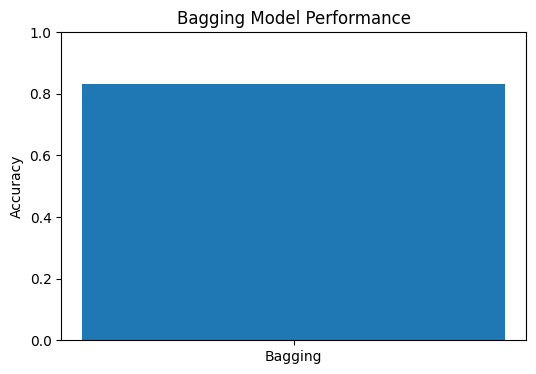

In [5]:
plt.figure(figsize=(6,4))

plt.bar(
    ["Bagging"],
    [bagging_accuracy]
)

plt.ylim(0,1)

plt.ylabel("Accuracy")
plt.title("Bagging Model Performance")

plt.show()

In [6]:
boosting_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2),
    n_estimators=50,
    random_state=42
)

boosting_model.fit(X_train, y_train)

boosting_pred = boosting_model.predict(X_test)

boosting_accuracy = accuracy_score(
    y_test,
    boosting_pred
)

print("AdaBoost Accuracy:", boosting_accuracy)

AdaBoost Accuracy: 0.8333333333333334


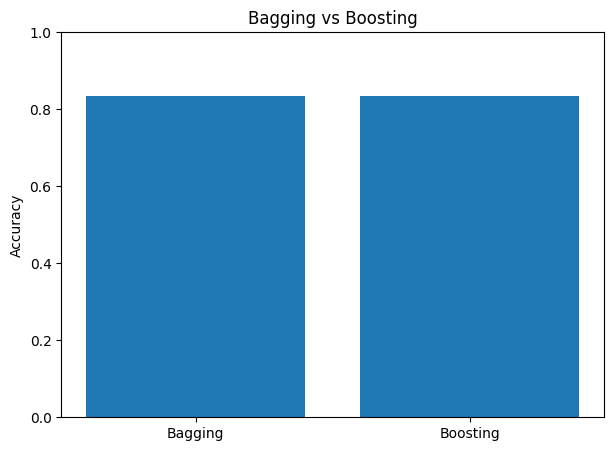

In [7]:
models = ["Bagging", "Boosting"]
accuracies = [bagging_accuracy, boosting_accuracy]

plt.figure(figsize=(7,5))

plt.bar(models, accuracies)

plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Bagging vs Boosting")

plt.show()

In [8]:
!pip install xgboost

In [9]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=50,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(
    y_test,
    xgb_pred
)

print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.8333333333333334


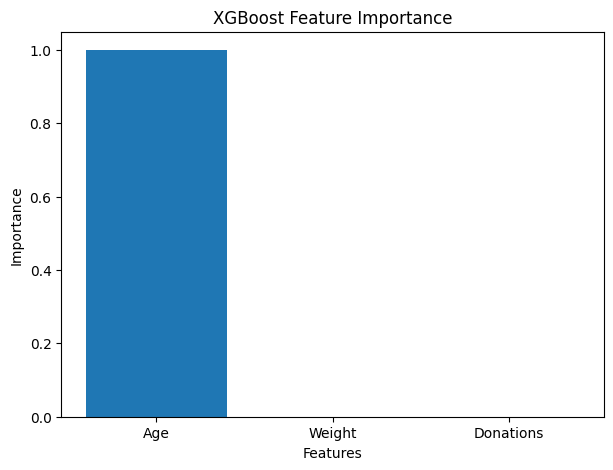

In [10]:
importance = xgb_model.feature_importances_

plt.figure(figsize=(7,5))

plt.bar(
    X.columns,
    importance
)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("XGBoost Feature Importance")

plt.show()

In [11]:
!pip install lightgbm

In [12]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    n_estimators=50,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    verbosity=-1
)

lgbm_model.fit(X_train, y_train)

lgbm_pred = lgbm_model.predict(X_test)

lgbm_accuracy = accuracy_score(
    y_test,
    lgbm_pred
)

print("LightGBM Accuracy:", lgbm_accuracy)

LightGBM Accuracy: 0.5


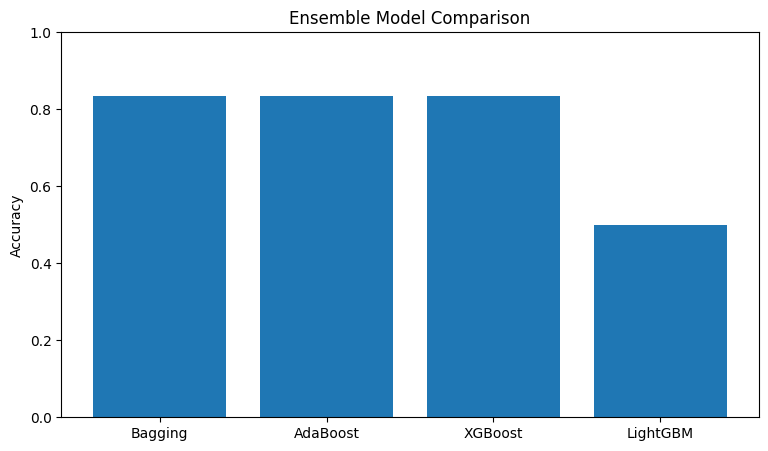

In [13]:
ensemble_models = [
    "Bagging",
    "AdaBoost",
    "XGBoost",
    "LightGBM"
]

ensemble_scores = [
    bagging_accuracy,
    boosting_accuracy,
    xgb_accuracy,
    lgbm_accuracy
]

plt.figure(figsize=(9,5))

plt.bar(
    ensemble_models,
    ensemble_scores
)

plt.ylim(0,1)

plt.ylabel("Accuracy")
plt.title("Ensemble Model Comparison")

plt.show()

In [14]:
train_scores = []
test_scores = []

depths = range(1, 11)

for depth in depths:
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_scores.append(
        model.score(X_train, y_train)
    )

    test_scores.append(
        model.score(X_test, y_test)
    )

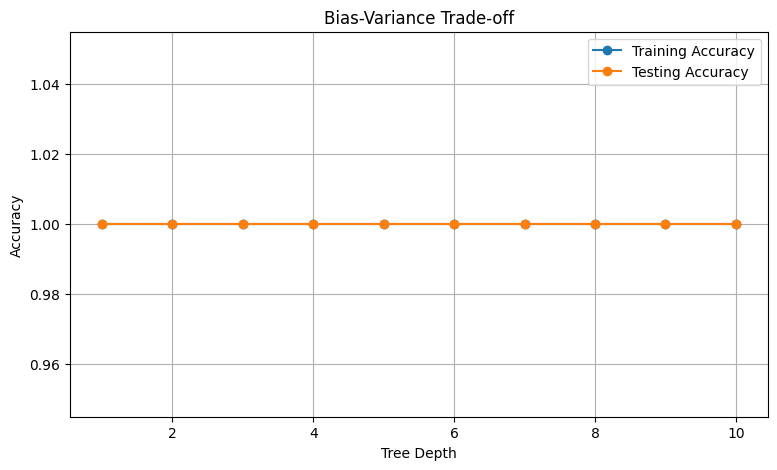

In [15]:
plt.figure(figsize=(9,5))

plt.plot(
    depths,
    train_scores,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    depths,
    test_scores,
    marker="o",
    label="Testing Accuracy"
)

plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")

plt.title("Bias-Variance Trade-off")

plt.legend()
plt.grid()

plt.show()

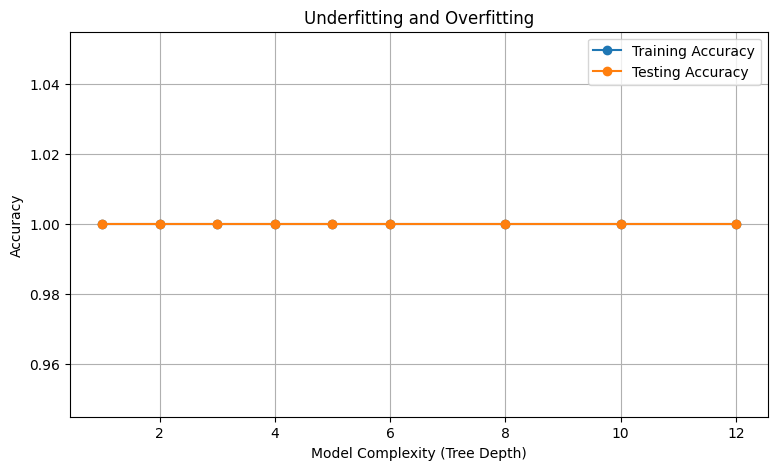

In [16]:
depths = [1, 2, 3, 4, 5, 6, 8, 10, 12]

train_accuracy = []
test_accuracy = []

for depth in depths:
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_accuracy.append(
        model.score(X_train, y_train)
    )

    test_accuracy.append(
        model.score(X_test, y_test)
    )

plt.figure(figsize=(9,5))

plt.plot(
    depths,
    train_accuracy,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    depths,
    test_accuracy,
    marker="o",
    label="Testing Accuracy"
)

plt.xlabel("Model Complexity (Tree Depth)")
plt.ylabel("Accuracy")

plt.title("Underfitting and Overfitting")

plt.legend()
plt.grid()

plt.show()

In [17]:
lasso_model = make_pipeline(
    StandardScaler(),
    Lasso(alpha=0.1)
)

lasso_model.fit(
    X_train,
    y_train
)

lasso_pred = lasso_model.predict(X_test)

print(
    "L1/Lasso MSE:",
    np.mean((y_test - lasso_pred) ** 2)
)

L1/Lasso MSE: 0.08301727720923


In [18]:
ridge_model = make_pipeline(
    StandardScaler(),
    Ridge(alpha=0.1)
)

ridge_model.fit(
    X_train,
    y_train
)

ridge_pred = ridge_model.predict(X_test)

print(
    "L2/Ridge MSE:",
    np.mean((y_test - ridge_pred) ** 2)
)

L2/Ridge MSE: 0.0878366973371749


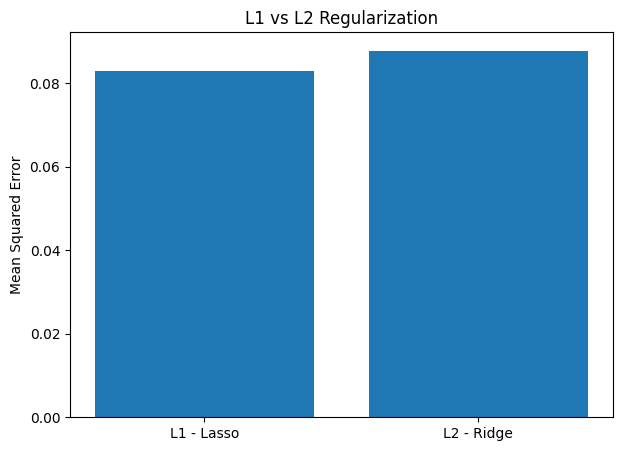

In [19]:
lasso_mse = np.mean((y_test - lasso_pred) ** 2)
ridge_mse = np.mean((y_test - ridge_pred) ** 2)

plt.figure(figsize=(7,5))

plt.bar(
    ["L1 - Lasso", "L2 - Ridge"],
    [lasso_mse, ridge_mse]
)

plt.ylabel("Mean Squared Error")
plt.title("L1 vs L2 Regularization")

plt.show()

In [20]:
results = pd.DataFrame({
    "Model": [
        "Bagging",
        "AdaBoost",
        "XGBoost",
        "LightGBM"
    ],
    "Accuracy": [
        bagging_accuracy,
        boosting_accuracy,
        xgb_accuracy,
        lgbm_accuracy
    ]
})

results

,Model,Accuracy
0,Bagging,0.833333
1,AdaBoost,0.833333
2,XGBoost,0.833333
3,LightGBM,0.500000


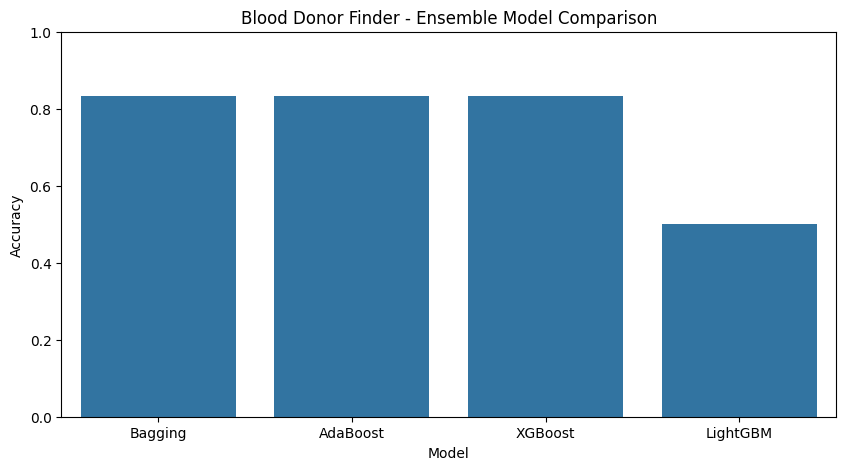

In [21]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.ylim(0,1)

plt.title("Blood Donor Finder - Ensemble Model Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model")

plt.show()